In [ ]:
pip install wfdb

In [ ]:
import numpy as np
import wfdb
import pywt
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import os
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path = '/content/drive/MyDrive/mit-bih-arrhythmia-database-1.0.0'

In [ ]:
# Function to load an individual ECG record and its annotations
def load_ecg_record(record_id, dataset_path=dataset_path):
    record = wfdb.rdrecord(f'{dataset_path}/{record_id}')
    annotations = wfdb.rdann(f'{dataset_path}/{record_id}', 'atr')
    return record, annotations


In [ ]:
# Function to augment the ECG signal
def augment_signal(signal):
    # Random shift in the range of -15 to 15 samples
    shift = np.random.randint(-15, 16)
    signal = np.roll(signal, shift)
    #Adding random noise
    noise = np.random.normal(0, 0.01, len(signal))
    signal += noise
    return signal

In [ ]:
# Function to denoise the ECG signal using wavelet transform
def denoise_signal(signal, wavelet='db6', level=2):
    coeff = pywt.wavedec(signal, wavelet, mode="per")
    sigma = (1 / 0.6745) * np.median(np.abs(coeff[-level] - np.median(coeff[-level])))
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))
    coeff[1:] = [pywt.threshold(i, value=uthresh, mode='soft') for i in coeff[1:]]
    reconstructed_signal = pywt.waverec(coeff, wavelet, mode='per')
    return reconstructed_signal

In [1]:
# Segment the ECG signal into fixed windows and assign labels based on annotations
def segment_ecg_fixed_windows_with_labels(record, annotations, window_size_samples):
    total_samples = record.p_signal.shape[0]
    ecg_segments = []
    segment_labels = []

    # Ensure annotations.sample and annotations.symbol are NumPy arrays
    annotation_samples = np.array(annotations.sample)
    annotation_symbols = np.array(annotations.symbol)

    label_mapping = {'N': 0, 'L': 1, 'R': 2, 'A': 3, 'V': 4}

    for start in range(0, total_samples - window_size_samples + 1, window_size_samples):
        end = start + window_size_samples
        segment = record.p_signal[start:end, 0]
        segment = augment_signal(segment)
        segment = denoise_signal(segment)

        # Get annotations within the current window
        annotation_idx = np.where((annotation_samples >= start) & (annotation_samples < end))[0]

        if annotation_idx.size > 0:
            symbols = annotation_symbols[annotation_idx]
            if symbols.size > 0:
                most_common_symbol = max(set(symbols), key=list(symbols).count)
                label = label_mapping.get(most_common_symbol, 0)
            else:
                label = label_mapping['N']
        else:
            label = label_mapping['N']

        ecg_segments.append(segment)
        segment_labels.append(label)

    return np.array(ecg_segments), np.array(segment_labels)

In [ ]:
# Processing all records from the dataset
sampling_rate = 360  # Sampling rate of MIT-BIH
window_size_seconds = 2  # Window size in seconds
window_size_samples = sampling_rate * window_size_seconds  # Number of samples per window

# List of record IDs from the MIT-BIH dataset
record_ids = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


all_segments = []
all_labels = []

for record_id in record_ids:
    record, annotations = load_ecg_record(record_id)
    segments, labels = segment_ecg_fixed_windows_with_labels(record, annotations, window_size_samples)
    all_segments.extend(segments)
    all_labels.extend(labels)

In [ ]:
# Normalize the data
scaler = StandardScaler()
all_segments = scaler.fit_transform(np.array(all_segments))

In [ ]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(all_segments, all_labels, test_size=0.3, random_state=42, stratify=all_labels)

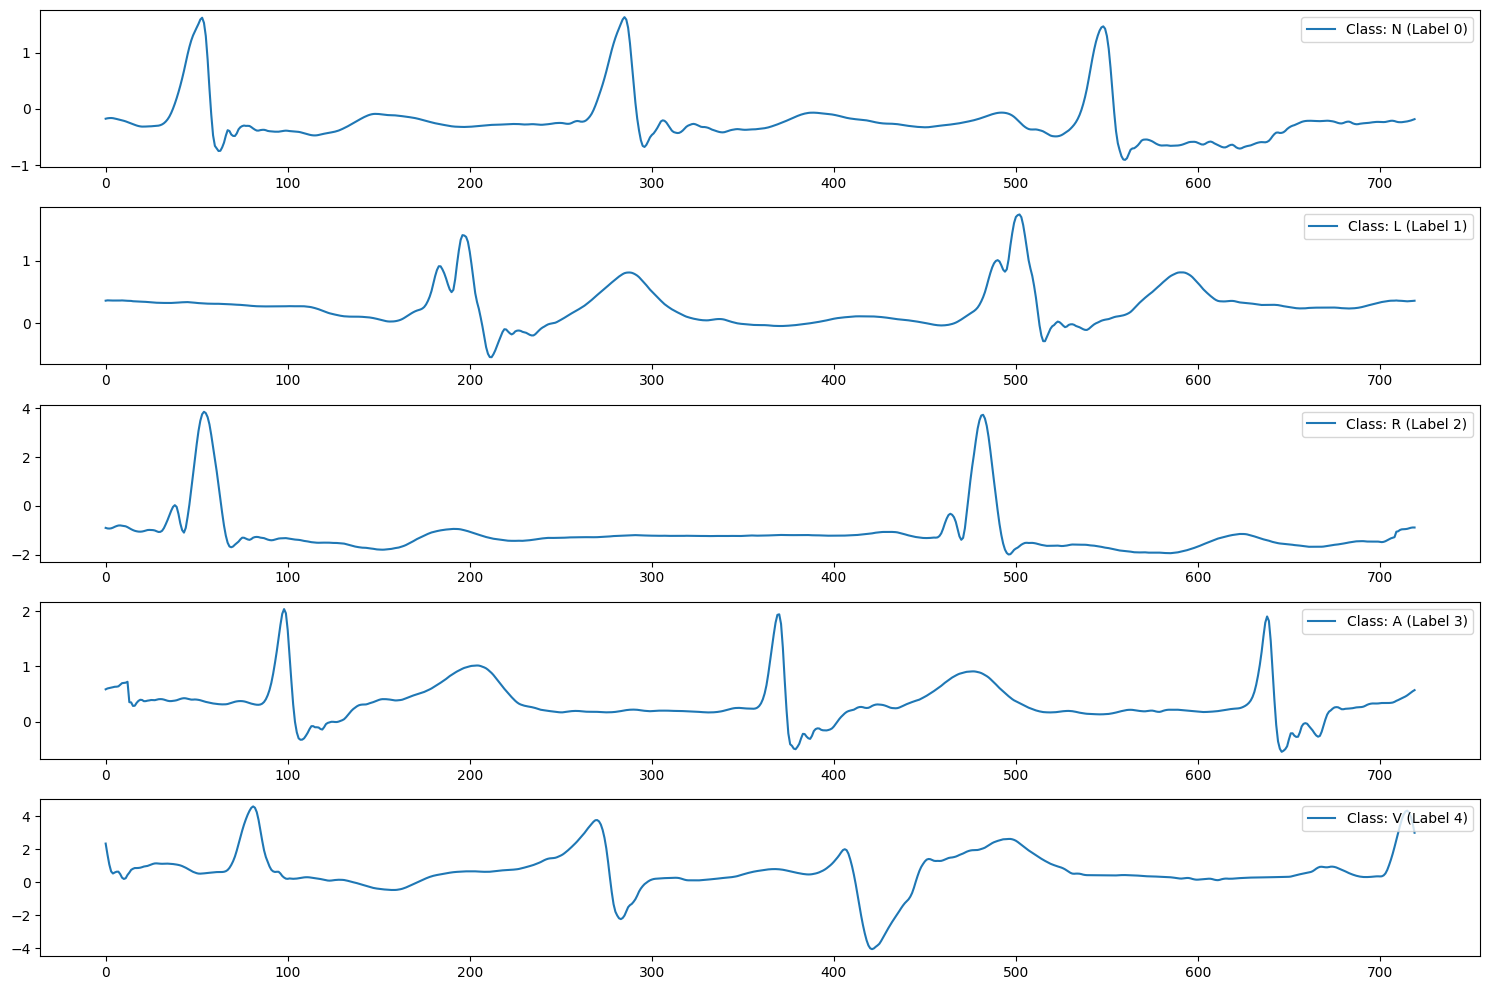

In [ ]:
#Plot a signal from each class
import matplotlib.pyplot as plt
import numpy as np

label_mapping = {'N': 0, 'L': 1, 'R': 2, 'A': 3, 'V': 4}


def plot_one_signal_per_class(X, y, label_mapping):
    # Create a reverse mapping from label number to label name
    reverse_label_mapping = {v: k for k, v in label_mapping.items()}

    # Find indices of one example per class
    unique_labels = np.unique(y)
    example_indices = []
    for label in unique_labels:
        example_index = np.where(y == label)[0][0]  # Get the index of the first occurrence of each label
        example_indices.append(example_index)

    
    plt.figure(figsize=(15, 10))
    for i, index in enumerate(example_indices):
        plt.subplot(len(unique_labels), 1, i + 1)
        plt.plot(X[index], label=f"Class: {reverse_label_mapping[y[index]]} (Label {y[index]})")
        plt.legend(loc="upper right")
        plt.tight_layout()

    plt.show()


plot_one_signal_per_class(X_train, y_train, label_mapping)


In [ ]:
# Convert y_train and y_test to numpy arrays
y_train = np.array(y_train)
y_test = np.array(y_test)

In [ ]:
# Reshape and resize to (150, 150, 1) after split
height, width, channels = 150, 150, 1
def resize_and_reshape(data):
    resized_data = np.zeros((data.shape[0], height, width, channels))
    for i in range(data.shape[0]):
        image = np.reshape(data[i], (data.shape[1], 1, 1))
        image_resized = tf.image.resize(image, (height, width))
        resized_data[i] = image_resized.numpy()
    return resized_data

X_train_resized = resize_and_reshape(X_train)
X_test_resized = resize_and_reshape(X_test)


In [ ]:
# Save the reshaped and resized datasets
np.save('/content/drive/MyDrive/SETS/X_train_resized.npy', X_train_resized)
np.save('/content/drive/MyDrive/SETS/y_train_resized.npy', y_train)
np.save('/content/drive/MyDrive/SETS/X_test_resized.npy', X_test_resized)
np.save('/content/drive/MyDrive/SETS/y_test_resized.npy', y_test)

In [ ]:
# Load the reshaped datasets
X_train_resized = np.load('/content/drive/MyDrive/SETS/X_train_resized.npy')
X_test_resized = np.load('/content/drive/MyDrive/SETS/X_test_resized.npy')
y_train = np.load('/content/drive/MyDrive/SETS/y_train_resized.npy')
y_test = np.load('/content/drive/MyDrive/SETS/y_test_resized.npy')

In [ ]:
# Preprocess the data
X_train_resized = tf.keras.applications.vgg16.preprocess_input(np.repeat(X_train_resized, 3, axis=-1))
X_test_resized = tf.keras.applications.vgg16.preprocess_input(np.repeat(X_test_resized, 3, axis=-1))

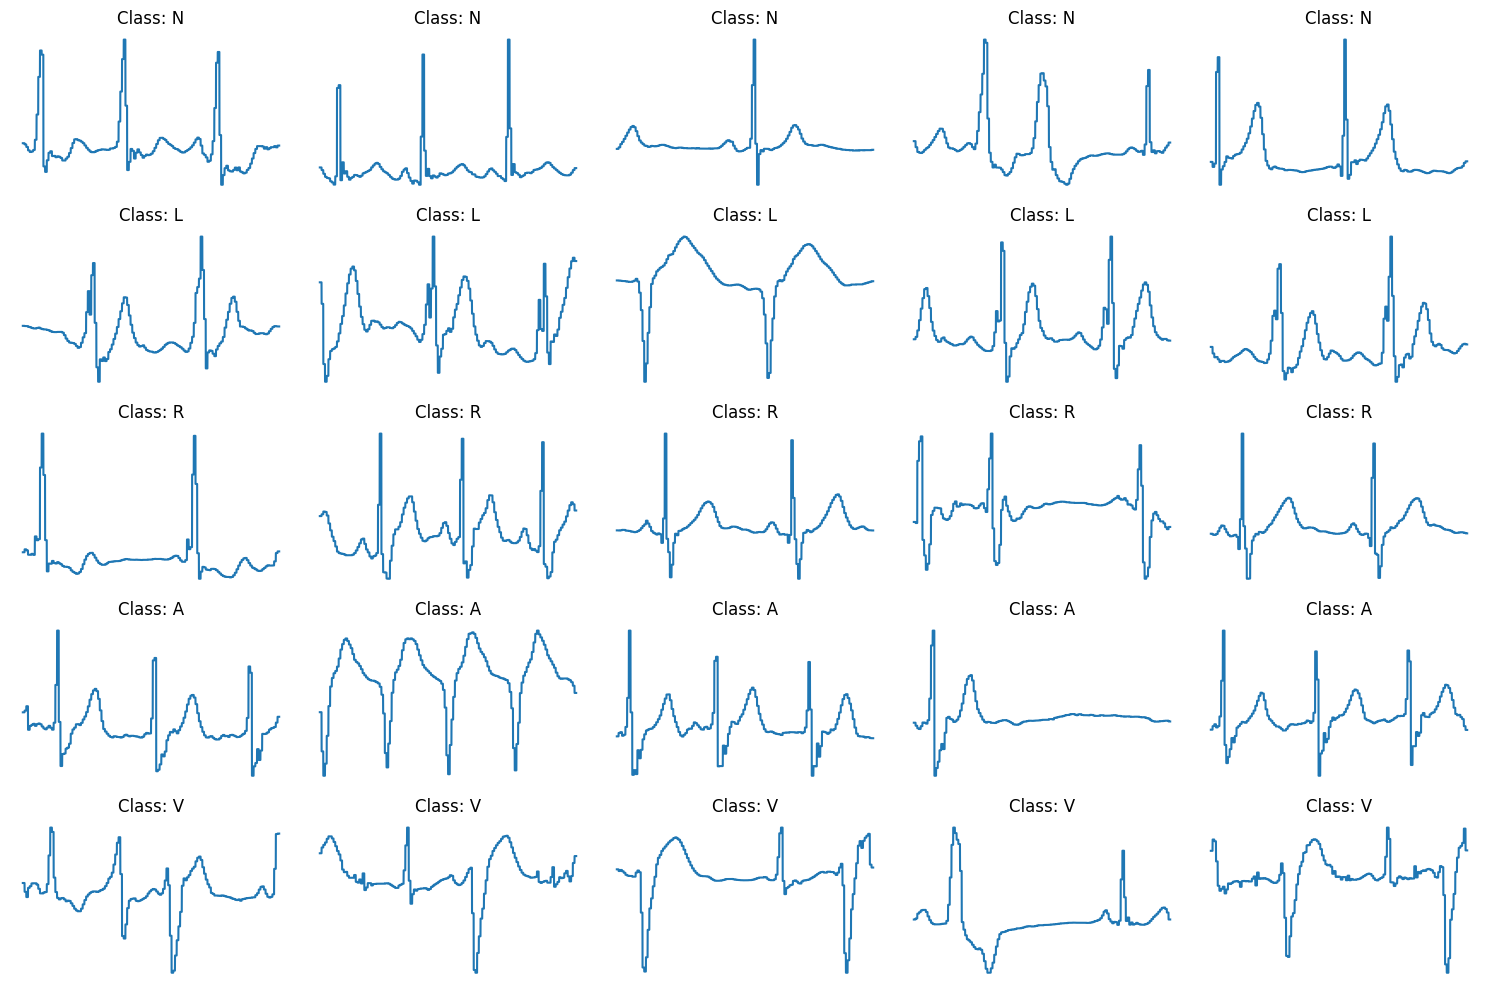

In [ ]:
# Plot the signals after reshaping
def plot_reshaped_signals(X, y, label_mapping, num_examples=5, channel=0):

    reverse_label_mapping = {v: k for k, v in label_mapping.items()}
    unique_labels = np.unique(y)

    plt.figure(figsize=(15, 10))

    for label in unique_labels:
        indices = np.where(y == label)[0]
        for i in range(min(num_examples, len(indices))):
            index = indices[i]
            signal = X[index, :, :, channel].reshape(-1)  # Select the specified channel and flatten to 1D
            plt.subplot(len(unique_labels), num_examples, label * num_examples + i + 1)
            plt.plot(signal)
            plt.title(f"Class: {reverse_label_mapping[label]}")
            plt.axis('off')

    plt.tight_layout()
    plt.show()
# Call the function to plot the signals after reshaping
plot_reshaped_signals(X_train_resized, y_train, label_mapping)


In [ ]:
# Define the ResNet50 model
from tensorflow.keras.applications import ResNet50


base_model_resNet = ResNet50(weights='imagenet', include_top=False, input_shape=(height, width, 3))
x = base_model_resNet.output
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(5, activation='softmax')(x)
model_resNet = Model(inputs=base_model_resNet.input, outputs=predictions)

# Freeze the base model layers
for layer in base_model_resNet.layers:
    layer.trainable = False

# Compile the model
model_resNet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
checkpoint_path = '/content/drive/MyDrive/MODElS/resNet.h5'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max')


94765736/94765736 [==============================] - 0s 0us/step


In [ ]:
# Train the model
history = model_resNet.fit(
    X_train_resized, y_train,
    epochs=50,
    validation_data=(X_test_resized, y_test),
    callbacks=[early_stopping, checkpoint]
)

# Evaluate the model
train_accuracy = model_resNet.evaluate(X_train_resized, y_train, verbose=0)[1]
test_accuracy = model_resNet.evaluate(X_test_resized, y_test, verbose=0)[1]

print(f"Training Accuracy: {train_accuracy}, Test Accuracy: {test_accuracy}")

Epoch 1/50
948/948 [==============================] - ETA: 0s - loss: 0.4085 - accuracy: 0.8653

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


948/948 [==============================] - 42s 38ms/step - loss: 0.4085 - accuracy: 0.8653 - val_loss: 0.2965 - val_accuracy: 0.8981
Epoch 2/50
948/948 [==============================] - 20s 21ms/step - loss: 0.2494 - accuracy: 0.9164 - val_loss: 0.2659 - val_accuracy: 0.9092
Epoch 3/50
948/948 [==============================] - 20s 21ms/step - loss: 0.2009 - accuracy: 0.9322 - val_loss: 0.2243 - val_accuracy: 0.9285
Epoch 4/50
948/948 [==============================] - 18s 19ms/step - loss: 0.1801 - accuracy: 0.9392 - val_loss: 0.2729 - val_accuracy: 0.9162
Epoch 5/50
948/948 [==============================] - 18s 19ms/step - loss: 0.1643 - accuracy: 0.9447 - val_loss: 0.2406 - val_accuracy: 0.9189
Epoch 6/50
948/948 [==============================] - 20s 21ms/step - loss: 0.1489 - accuracy: 0.9480 - val_loss: 0.2134 - val_accuracy: 0.9302
Epoch 7/50
948/948 [==============================] - 18s 19ms/step - loss: 0.1349 - accuracy: 0.9539 - val_loss: 0.2583 - val_accuracy: 0.9182
Epo

In [ ]:
from tensorflow.keras.models import load_model
model_path = '/content/drive/MyDrive/MODElS/resNet.h5'
loaded_model = load_model(model_path)

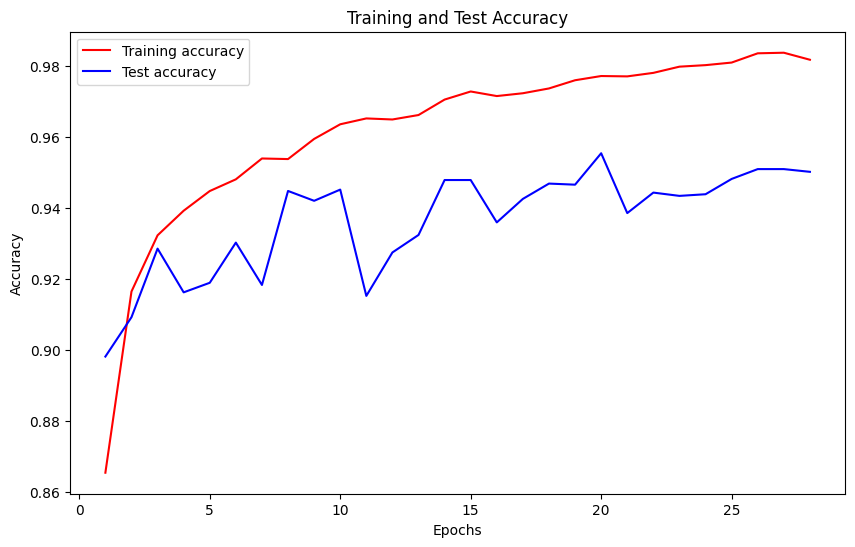

In [ ]:
# Plot training and test accuracies over epochs
import matplotlib.pyplot as plt


acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)  # Number of epochs


plt.figure(figsize=(10, 6))
plt.plot(epochs, acc, 'r', label='Training accuracy')  # 'bo' gives blue color and dot markers
plt.plot(epochs, val_acc, 'b', label='Test accuracy')   # 'b' gives solid blue line
plt.title('Training and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Generate predictions
y_pred = loaded_model.predict(X_test_resized)
y_pred_classes = np.argmax(y_pred, axis=1)

406/406 [==============================] - 6s 12ms/step


In [ ]:
# Print classification report
class_report = classification_report(y_test, y_pred_classes, target_names=['N', 'L', 'R', 'A', 'V'])
print("\nClassification Report:\n", class_report)


Classification Report:
               precision    recall  f1-score   support

           N       0.97      0.97      0.97     10075
           L       0.94      0.97      0.96       971
           R       0.95      0.94      0.94       976
           A       0.84      0.78      0.81       250
           V       0.77      0.76      0.76       717

    accuracy                           0.96     12989
   macro avg       0.90      0.89      0.89     12989
weighted avg       0.96      0.96      0.96     12989



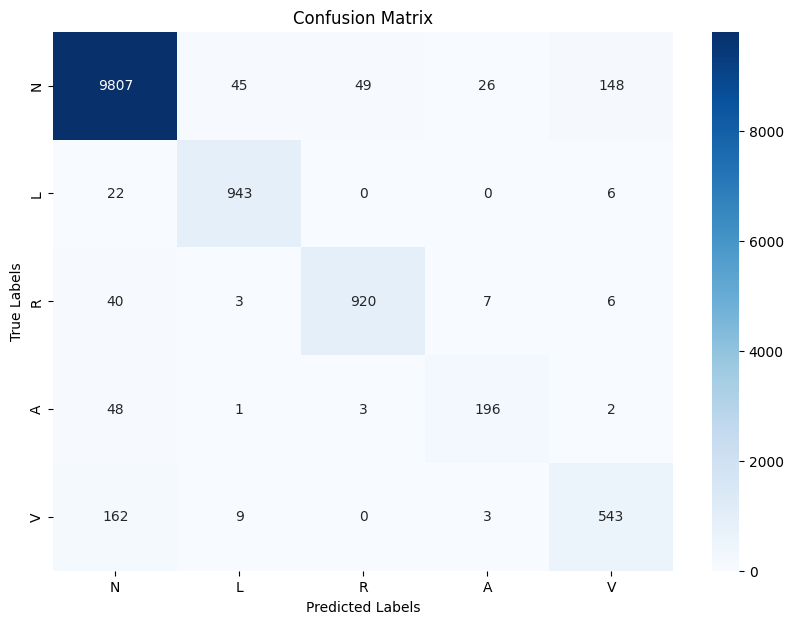

In [ ]:
# Compute and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['N', 'L', 'R', 'A', 'V'], yticklabels=['N', 'L', 'R', 'A', 'V'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

406/406 [==============================] - 5s 12ms/step


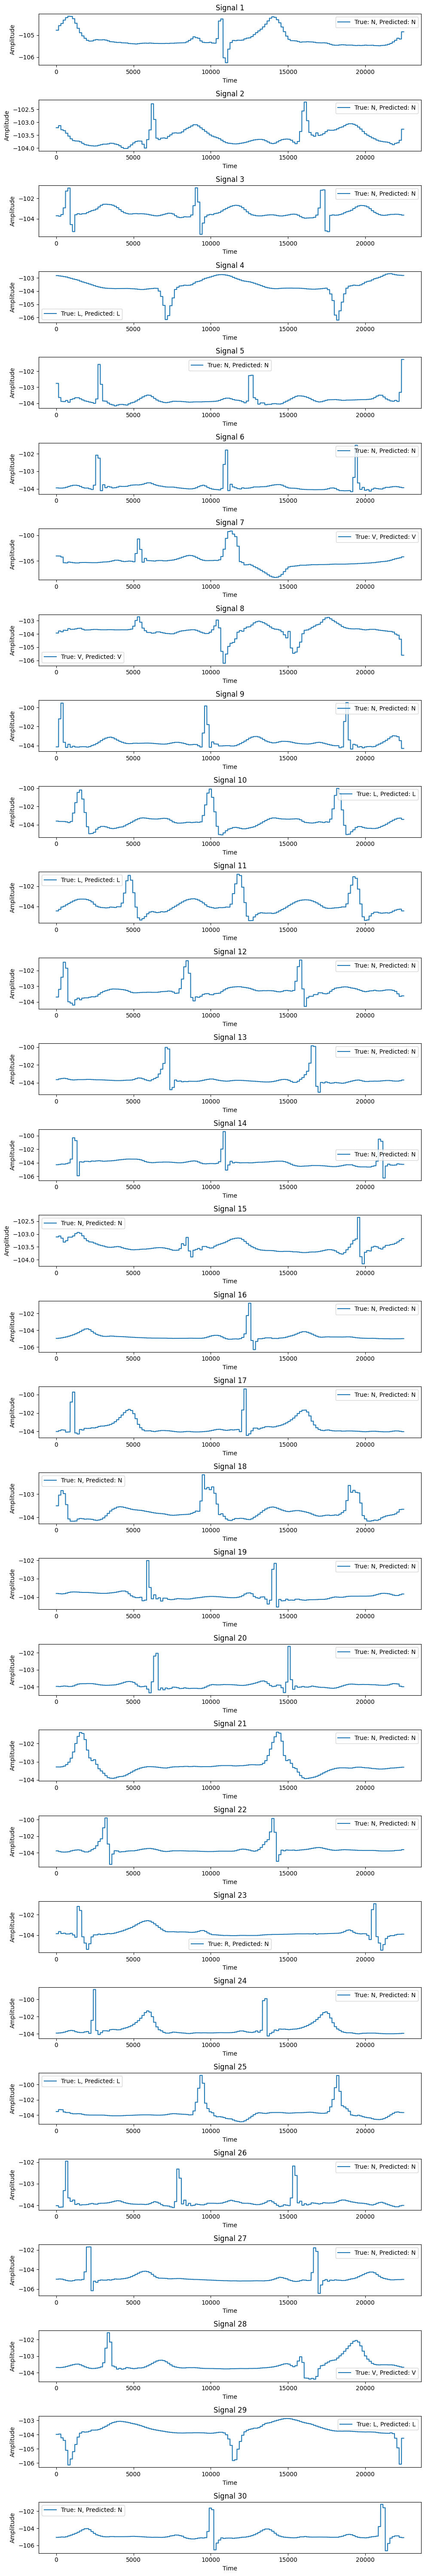

Correct Predictions: 12409
Incorrect Predictions: 580


In [ ]:
# Plot sample signals with true and predicted labels, and display prediction accuracy
def plot_and_predict(X_test, y_test, model, label_mapping, num_samples=10, channel=0):

    # Ensure num_samples does not exceed length of X_test
    num_samples = min(num_samples, len(X_test))

    # Predict the labels
    predictions = model.predict(X_test)
    predicted_labels = np.argmax(predictions, axis=1)

    # Count correct and incorrect predictions
    correct = np.sum(predicted_labels == y_test)
    incorrect = len(y_test) - correct

    # Reverse label mapping
    reverse_label_mapping = {v: k for k, v in label_mapping.items()}

    # Start plotting
    fig, axes = plt.subplots(num_samples, 1, figsize=(10, num_samples * 2))
    if num_samples == 1:
        axes = [axes]  # Make it iterable

    for i, ax in enumerate(axes):
        signal = X_test[i, :, :, channel].flatten()  # Flatten to 1D for plotting
        true_label = reverse_label_mapping[y_test[i]]
        predicted_label = reverse_label_mapping[predicted_labels[i]]
        ax.plot(signal, label=f'True: {true_label}, Predicted: {predicted_label}')
        ax.legend()
        ax.set_title(f'Signal {i+1}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Amplitude')

    plt.tight_layout()
    plt.show()

    print(f"Correct Predictions: {correct}")
    print(f"Incorrect Predictions: {incorrect}")


plot_and_predict(X_test_resized, y_test, loaded_model, {'N': 0, 'L': 1, 'R': 2, 'A': 3, 'V': 4}, num_samples=30)